# Module M8.1 — LIME Explainability & SHAP Agreement Validation

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Roadmap ref:** Phase 8 → Module M8.1  

### Sections
1. Environment setup  
2. Load FINAL_DEPLOYMENT_MODEL and SHAP outputs  
3. Initialize LIME explainer  
4. Generate TP / TN / FP / FN explanations  
5. SHAP vs LIME agreement analysis  
6. Feature consistency report  
7. High-disagreement case analysis  
8. Export all reports  


## 0. Environment Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns

from src.utils.logger                   import get_logger
from src.training.model_saver           import load_all_models
from src.training.model_registry        import MODEL_DISPLAY_NAMES
from src.explainability.shap_explainer  import compute_shap_values
from src.explainability.shap_global     import run_global_analysis
from src.explainability.lime_explainer  import (
    build_lime_explainer, explain_sample, is_native_lime
)
from src.explainability.lime_local      import run_lime_local
from src.explainability.shap_lime_comparator import run_comparison
from src.explainability.lime_report     import generate_lime_report

logger = get_logger('notebook.08_lime')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print(f'LIME backend : {"native" if is_native_lime() else "fallback"}')
print('Imports OK ✓')


2026-06-17 21:01:05 | INFO     | src.explainability.shap_explainer        | shap 0.51.0 available — using native SHAP
2026-06-17 21:01:05 | INFO     | src.explainability.lime_explainer        | lime library available — using native LimeTabularExplainer


LIME backend : native
Imports OK ✓


## 1. Path Configuration

In [3]:
MODELS_DIR    = PROJECT_ROOT / 'outputs' / 'models'
PROCESSED_DIR = PROJECT_ROOT / 'data'    / 'processed'
REPORTS_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_LIME    = PROJECT_ROOT / 'outputs' / 'plots'   / 'lime'
LOCAL_REPORTS = REPORTS_DIR  / 'lime_local_explanations'

for p in [REPORTS_DIR, PLOTS_LIME, LOCAL_REPORTS,
          PLOTS_LIME/'tp', PLOTS_LIME/'tn',
          PLOTS_LIME/'fp', PLOTS_LIME/'fn']:
    p.mkdir(parents=True, exist_ok=True)
print('Paths configured ✓')


Paths configured ✓


## 2. Load Model and Data

In [4]:
bench   = pd.read_csv(REPORTS_DIR / 'evaluation_metrics.csv')
best_B  = bench[bench.track=='B'].sort_values('roc_auc', ascending=False).iloc[0]
id_map  = {v:k for k,v in MODEL_DISPLAY_NAMES.items()}
best_id = id_map.get(best_B['model'], 'logistic_regression')

FINAL_DEPLOYMENT_MODEL = load_all_models(MODELS_DIR, 'B')[best_id]
print(f'FINAL_DEPLOYMENT_MODEL: {best_B["model"]} ({type(FINAL_DEPLOYMENT_MODEL).__name__})')

X_train_B = pd.read_csv(PROCESSED_DIR / 'track_B' / 'X_train.csv')
X_test_B  = pd.read_csv(PROCESSED_DIR / 'track_B' / 'X_test.csv')
y_test    = pd.read_csv(PROCESSED_DIR / 'y_test.csv')['label']

LIME_feature_names  = list(X_test_B.columns)
LIME_X_train_np     = X_train_B.values.astype(float)
LIME_X_test_np      = X_test_B.values.astype(float)
LIME_predict_fn     = FINAL_DEPLOYMENT_MODEL.predict_proba

print(f'X_train_B shape: {X_train_B.shape}')
print(f'X_test_B  shape: {X_test_B.shape}')
print(f'y_test    count: {len(y_test):,}')


2026-06-17 21:01:05 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\logistic_regression.pkl
2026-06-17 21:01:05 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\random_forest.pkl
2026-06-17 21:01:05 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\xgboost.pkl
2026-06-17 21:01:05 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\lightgbm.pkl
2026-06-17 21:01:05 | INFO     | src.training.model_saver                 | Loaded 4/4 Track B models


FINAL_DEPLOYMENT_MODEL: Logistic Regression (LogisticRegression)
X_train_B shape: (188296, 56)
X_test_B  shape: (47074, 56)
y_test    count: 47,074


## 3. Compute SHAP Values (for comparison)

In [5]:
# Load or recompute SHAP values needed for comparison
shap_ranking_df = pd.read_csv(REPORTS_DIR / 'shap_feature_ranking.csv')
print(f'SHAP feature ranking loaded: {len(shap_ranking_df)} features')
print('Top-5 SHAP features:')
print(shap_ranking_df.head(5)[['feature','mean_abs_shap','rank']].to_string(index=False))


SHAP feature ranking loaded: 56 features
Top-5 SHAP features:
         feature  mean_abs_shap  rank
LetterRatioInURL       3.046976     1
      LineOfCode       3.032714     2
         IsHTTPS       2.683940     3
 NoOfDegitsInURL       2.508461     4
    DomainLength       2.054936     5


In [6]:
# Recompute SHAP values for comparison (small sample)
print('Computing SHAP values (500 samples) for agreement analysis ...')
shap_result = compute_shap_values(
    model        = FINAL_DEPLOYMENT_MODEL,
    X_background = X_train_B,
    X_explain    = X_test_B,
    feature_names= LIME_feature_names,
    sample_n     = 500,
    random_state = 42,
)
print(f'SHAP values shape: {shap_result.shap_values.shape}')
print(f'Native SHAP      : {shap_result.is_native_shap}')


2026-06-17 21:01:08 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 500 test rows
2026-06-17 21:01:09 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 500 samples …
2026-06-17 21:01:09 | INFO     | src.explainability.shap_explainer        | Native SHAP complete: shap_values shape=(500, 56)  expected_value=-0.178819


Computing SHAP values (500 samples) for agreement analysis ...
SHAP values shape: (500, 56)
Native SHAP      : True


## 4. Initialize LIME Explainer

In [7]:
print('Building LIME explainer ...')
lime_explainer = build_lime_explainer(
    X_background  = LIME_X_train_np,
    feature_names = LIME_feature_names,
    class_names   = ('phishing', 'legitimate'),
    mode          = 'classification',
    random_state  = 42,
)
print(f'LIME backend: {"native" if is_native_lime() else "FallbackLIMEExplainer"}')
print(f'Background rows: {LIME_X_train_np.shape[0]:,}')


Building LIME explainer ...


2026-06-17 21:01:12 | INFO     | src.explainability.lime_explainer        | LimeTabularExplainer (native) built on 188,296 background rows


LIME backend: native
Background rows: 188,296


## 5. Generate TP / TN / FP / FN LIME Explanations

In [8]:
print('Generating LIME explanations for all categories ...')
lime_local_r = run_lime_local(
    explainer     = lime_explainer,
    predict_fn    = LIME_predict_fn,
    X_test        = LIME_X_test_np,
    y_test        = y_test.values,
    feature_names = LIME_feature_names,
    model         = FINAL_DEPLOYMENT_MODEL,
    n_per_class   = 10,
    n_lime_feats  = 10,
    n_lime_samp   = 2000,
    plots_dir     = PLOTS_LIME,
    reports_dir   = LOCAL_REPORTS,
    random_state  = 42,
)

print('Sample counts generated:')
for cat, cnt in lime_local_r['category_counts'].items():
    print(f'  {cat.upper()}: {cnt} samples')


2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            | =======================================================
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            | M8.1 — LOCAL LIME ANALYSIS
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            | =======================================================
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            |   LIME TP: 26,970 available → 10 selected
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            |   LIME TN: 20,101 available → 10 selected
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            |   LIME FP: 0 available → 0 selected
2026-06-17 21:01:12 | INFO     | src.explainability.lime_local            |   LIME FN: 3 available → 3 selected


Generating LIME explanations for all categories ...


2026-06-17 21:01:17 | INFO     | src.explainability.lime_local            |   TP: 10 samples → 10 explanations
2026-06-17 21:01:22 | INFO     | src.explainability.lime_local            |   TN: 10 samples → 10 explanations
2026-06-17 21:01:22 | INFO     | src.explainability.lime_local            |   FP: 0 samples → 0 explanations
2026-06-17 21:01:23 | INFO     | src.explainability.lime_local            |   FN: 3 samples → 3 explanations
2026-06-17 21:01:23 | INFO     | src.explainability.lime_local            | Local LIME complete: 23 explanations generated


Sample counts generated:
  TP: 10 samples
  TN: 10 samples
  FP: 0 samples
  FN: 3 samples


In [9]:
# Preview one LIME explanation
for cat in ['tp','tn','fp','fn']:
    results = lime_local_r['lime_results'].get(cat, [])
    if results:
        lr = results[0]
        print(f'\n{cat.upper()} sample {lr.sample_idx}  '
              f'P(Legit)={lr.prediction_proba:.4f}  R²={lr.local_r2:.4f}')
        for feat, contrib in lr.top_features[:5]:
            print(f'  {feat:<35}: {contrib:+.4f}')



TP sample 3971  P(Legit)=1.0000  R²=0.2132
  NoOfDegitsInURL <= 0.00            : +0.3152
  IsDomainIP <= 0.00                 : -0.3002
  LineOfCode > 0.26                  : +0.2586
  NoOfOtherSpecialCharsInURL <= 0.00 : +0.1622
  NoOfAmpersandInURL <= 0.00         : -0.1514

TN sample 36889  P(Legit)=0.0000  R²=0.3935
  NoOfDegitsInURL <= 0.00            : +0.3748
  LetterRatioInURL > 0.47            : -0.3601
  LineOfCode <= -0.74                : -0.3339
  NoOfAmpersandInURL <= 0.00         : -0.1750
  NoOfOtherSpecialCharsInURL <= 0.00 : +0.1328

FN sample 30588  P(Legit)=0.8835  R²=0.2114
  NoOfObfuscatedChar <= 0.00         : +0.3878
  NoOfDegitsInURL <= 0.00            : +0.3541
  DomainLength <= -0.55              : -0.2414
  NoOfOtherSpecialCharsInURL <= 0.00 : +0.1219
  HasExternalFormSubmit <= 0.00      : +0.0999


TP example:


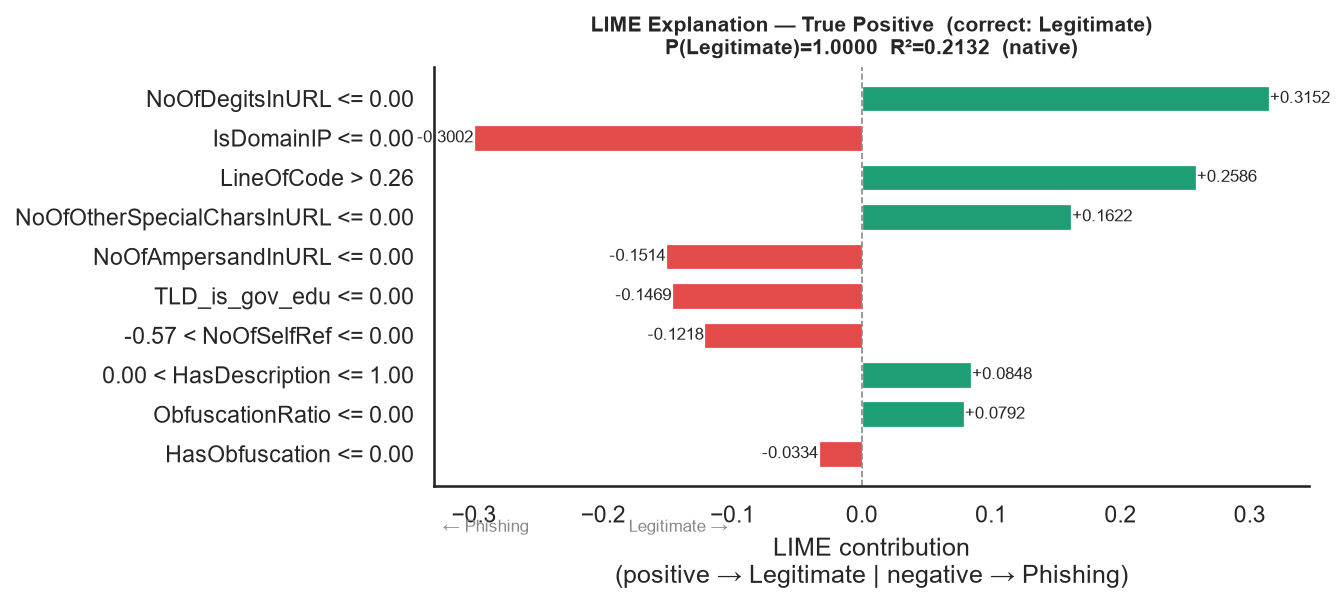

TN example:


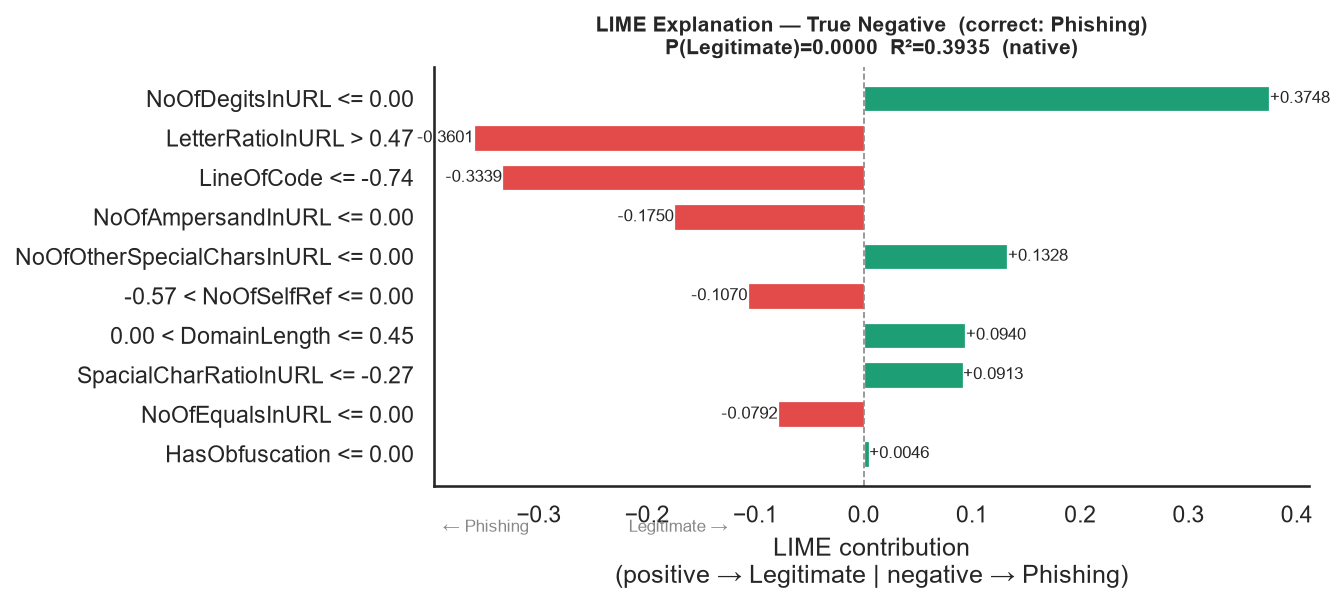

FN example:


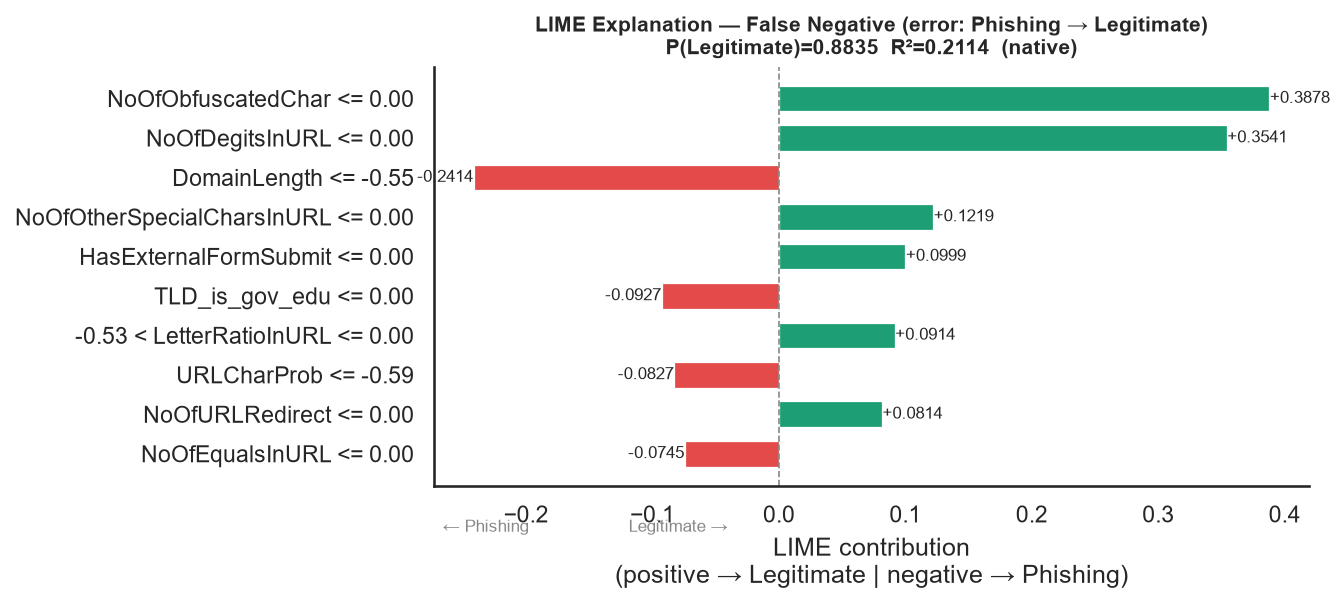

In [10]:
# Display contribution plots
from IPython.display import Image
for cat in ['tp','tn','fp','fn']:
    plots = lime_local_r['plot_paths'].get(cat, [])
    if plots:
        print(f'{cat.upper()} example:')
        display(Image(str(plots[0])))


## 6. SHAP vs LIME Agreement Analysis

In [11]:
comparison_r = run_comparison(
    shap_result      = shap_result,
    lime_local_r     = lime_local_r,
    shap_ranking_df  = shap_ranking_df,
    feature_names    = LIME_feature_names,
    plots_dir        = PLOTS_LIME,
    reports_dir      = REPORTS_DIR,
    top_k            = 5,
    top_n_global     = 20,
)

global_metrics = comparison_r['global_metrics']
consistency    = comparison_r['consistency']

print(f"Mean agreement        : {global_metrics['mean']:.4f}")
print(f"Median agreement      : {global_metrics['median']:.4f}")
print(f"Min / Max             : {global_metrics['min']:.4f} / {global_metrics['max']:.4f}")
print(f"High-disagree (<0.4)  : {global_metrics['n_high_disagree']} samples")
print(f"Feature consistency   : {consistency['consistency_score']:.4f}")
print(f"Shared features (top-20): {len(consistency['shared'])}")


2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | =======================================================
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | M8.1 — SHAP vs LIME AGREEMENT ANALYSIS
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | =======================================================
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | Per-sample agreement computed: 23 samples  mean=0.0000  min=0.0000
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | Saved: shap_lime_agreement.csv
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | Saved: high_disagreement_cases.csv  (23 cases)
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | Agreement summary: mean=0.0000  high-disagree=23
2026-06-17 21:01:23 | INFO     | src.explainability.shap_lime_comparator  | Feature consistency: shared=10/20  SHAP-only=10

Mean agreement        : 0.0000
Median agreement      : 0.0000
Min / Max             : 0.0000 / 0.0000
High-disagree (<0.4)  : 23 samples
Feature consistency   : 0.5000
Shared features (top-20): 10


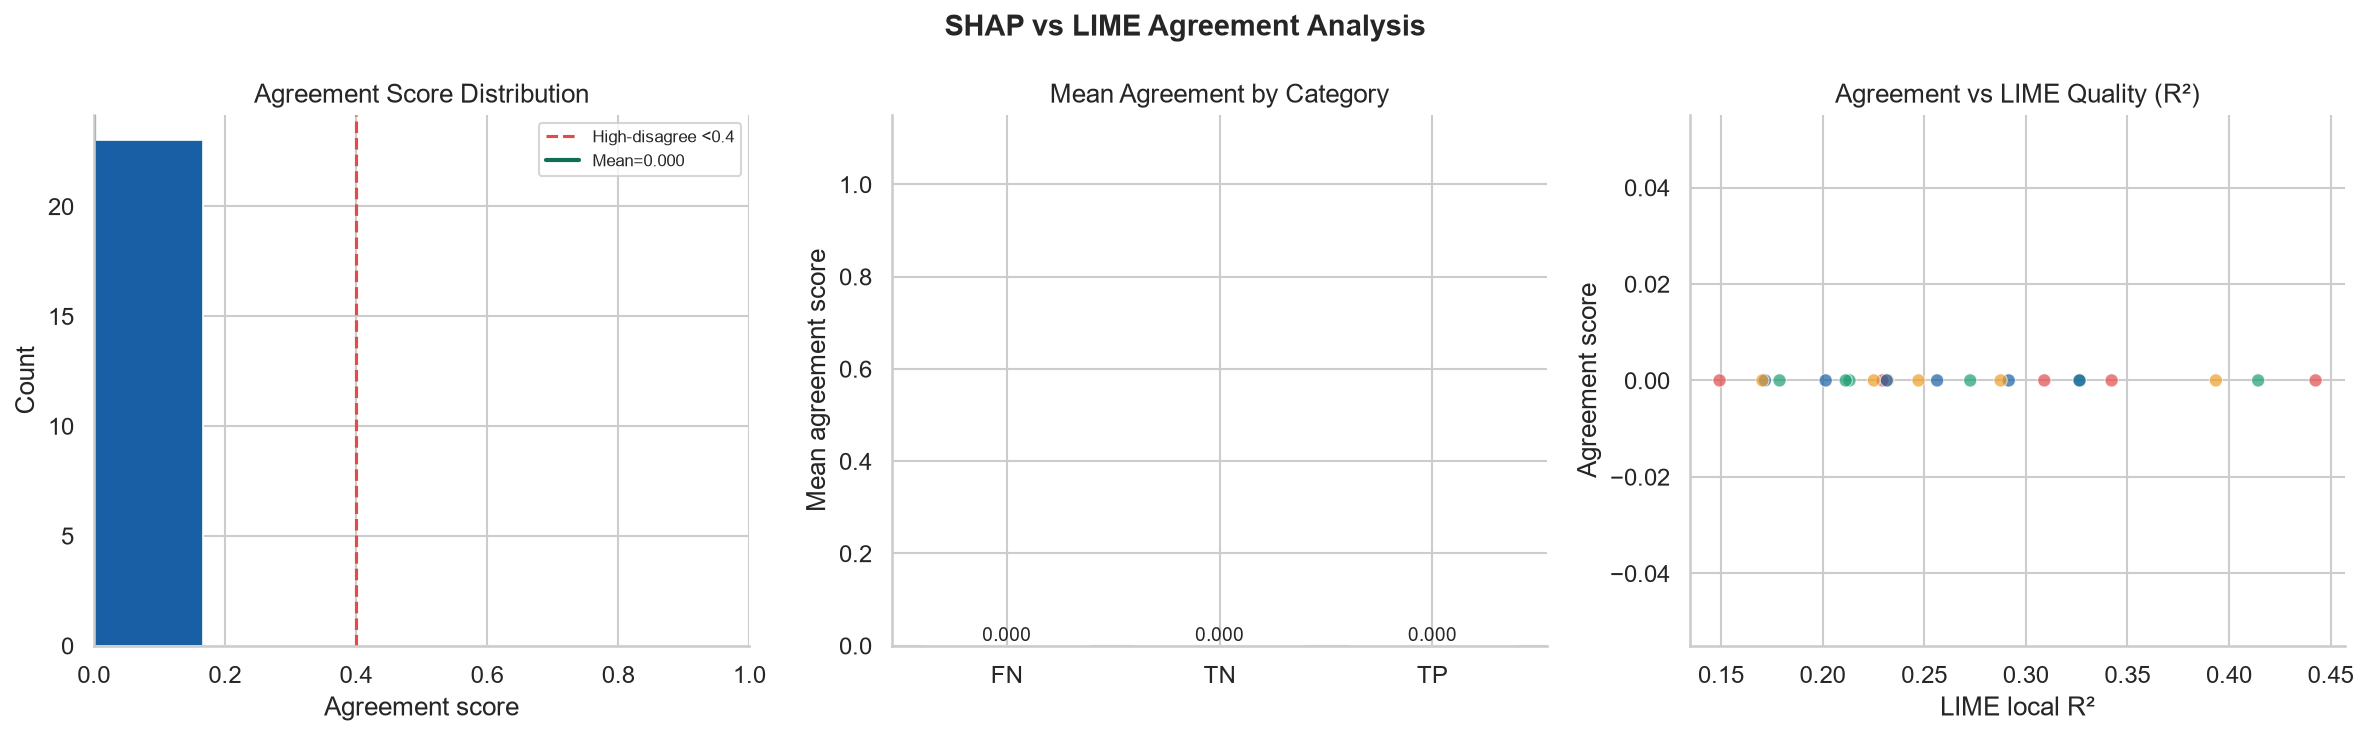

In [12]:
from IPython.display import Image
if comparison_r['agreement_plot_path'].exists():
    display(Image(str(comparison_r['agreement_plot_path'])))


## 7. Agreement Table & High-Disagreement Cases

In [13]:
agreement_df = comparison_r['agreement_df']
print(f'Agreement table shape: {agreement_df.shape}')
display(agreement_df[['sample_id','category','overlap_count','agreement_score','local_r2']]
        .sort_values('agreement_score', ascending=False).head(15))


Agreement table shape: (23, 10)


,sample_id,category,overlap_count,agreement_score,local_r2
0,3971,tp,0,0.0,0.213225
1,36372,tp,0,0.0,0.171613
2,4147,tp,0,0.0,0.232053
3,30744,tp,0,0.0,0.229536
4,20604,tp,0,0.0,0.272654
5,20324,tp,0,0.0,0.291622
6,32758,tp,0,0.0,0.225229
7,4397,tp,0,0.0,0.149308
8,9346,tp,0,0.0,0.178823
9,40392,tp,0,0.0,0.201537


In [14]:
high_dis = comparison_r['high_disagree_df']
print(f'High-disagreement cases: {len(high_dis)}')
if not high_dis.empty:
    display(high_dis[['sample_id','category','agreement_score','local_r2']].head(10))


High-disagreement cases: 23


,sample_id,category,agreement_score,local_r2
0,3971,tp,0.0,0.213225
1,36372,tp,0.0,0.171613
2,4147,tp,0.0,0.232053
3,30744,tp,0.0,0.229536
4,20604,tp,0.0,0.272654
5,20324,tp,0.0,0.291622
6,32758,tp,0.0,0.225229
7,4397,tp,0.0,0.149308
8,9346,tp,0.0,0.178823
9,40392,tp,0.0,0.201537


## 8. Feature Consistency

In [15]:
lime_ranking = consistency['lime_global_ranking']
print('Top-20 LIME global ranking:')
display(lime_ranking.head(20))

print(f'\nShared with SHAP top-20 ({len(consistency["shared"])}):')
print(', '.join(consistency['shared']))

print(f'\nSHAP-only ({len(consistency["shap_only"])}):')
print(', '.join(consistency['shap_only']))

print(f'\nLIME-only ({len(consistency["lime_only"])}):')
print(', '.join(consistency['lime_only']))


Top-20 LIME global ranking:


,feature,total_abs_contribution,rank
0,NoOfDegitsInURL,7.986795,1
1,NoOfAmpersandInURL,4.089915,2
2,LetterRatioInURL,4.036039,3
3,LineOfCode,3.441183,4
4,NoOfOtherSpecialCharsInURL,2.693684,5
5,DomainLength,2.585850,6
6,ObfuscationRatio,2.166829,7
7,IsDomainIP,2.066445,8
8,NoOfObfuscatedChar,2.052191,9
9,LargestLineLength,1.520513,10



Shared with SHAP top-20 (10):
DomainLength, LargestLineLength, LetterRatioInURL, LineOfCode, NoOfDegitsInURL, NoOfExternalRef, NoOfOtherSpecialCharsInURL, NoOfSelfRef, SpacialCharRatioInURL, URLCharProb

SHAP-only (10):
ContentComplexityScore, DomainTitleMatchScore, HasCopyrightInfo, HasDescription, HasSocialNet, IsHTTPS, NoOfImage, NoOfJS, SubdomainRatio, TrustBadgeScore

LIME-only (10):
Crypto, HasObfuscation, IsDomainIP, NoOfAmpersandInURL, NoOfEqualsInURL, NoOfObfuscatedChar, NoOfPopup, NoOfSelfRedirect, ObfuscationRatio, TLD


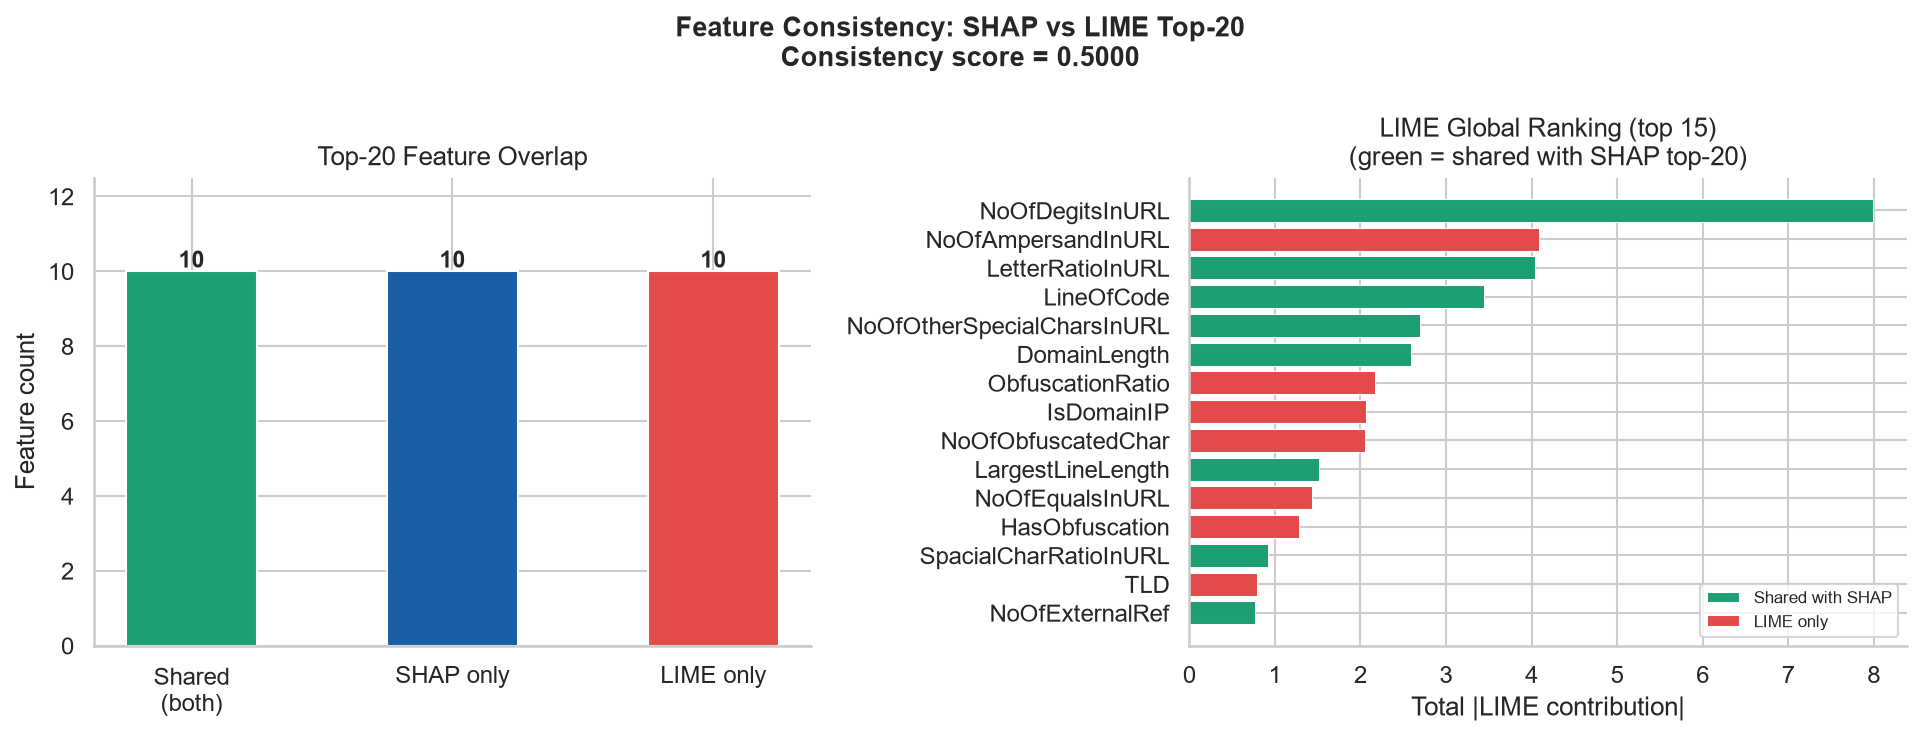

In [16]:
if comparison_r['consistency_plot_path'].exists():
    display(Image(str(comparison_r['consistency_plot_path'])))


## 9. Export HTML Report and Verify Artifacts

In [17]:
lime_backend = 'native' if is_native_lime() else 'fallback'

report_path = generate_lime_report(
    lime_local_r   = lime_local_r,
    comparison_r   = comparison_r,
    global_metrics = global_metrics,
    consistency    = consistency,
    lime_backend   = lime_backend,
    output_path    = REPORTS_DIR / 'lime_analysis_report.html',
    plots_dir      = PLOTS_LIME,
)
print(f'Report saved: {report_path}')


2026-06-17 21:01:25 | INFO     | src.explainability.lime_report           | LIME report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\lime_analysis_report.html


Report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\lime_analysis_report.html


In [18]:
import pathlib
artifacts = [
    'outputs/reports/shap_lime_agreement.csv',
    'outputs/reports/high_disagreement_cases.csv',
    'outputs/reports/lime_feature_ranking.csv',
    'outputs/reports/lime_summary.csv',
    'outputs/reports/lime_analysis_report.html',
    'outputs/plots/lime/shap_lime_agreement.png',
    'outputs/plots/lime/feature_consistency.png',
]
for rel in artifacts:
    p = PROJECT_ROOT / rel
    print(f"  {'✓' if p.exists() else '✗'}  {rel}")


  ✓  outputs/reports/shap_lime_agreement.csv
  ✓  outputs/reports/high_disagreement_cases.csv
  ✓  outputs/reports/lime_feature_ranking.csv
  ✓  outputs/reports/lime_summary.csv
  ✓  outputs/reports/lime_analysis_report.html
  ✓  outputs/plots/lime/shap_lime_agreement.png
  ✓  outputs/plots/lime/feature_consistency.png


## 10. Downstream Interface

In [19]:
MEAN_AGREEMENT = global_metrics['mean']
top_20_lime    = consistency['lime_global_ranking']
high_disagree_indices = comparison_r['high_disagree_df']['sample_id'].tolist()

print('=' * 65)
print('M8.1 COMPLETE — DOWNSTREAM INTERFACE')
print('=' * 65)
print()
print(f'A. Mean SHAP-LIME agreement     : {MEAN_AGREEMENT:.4f}')
print(f'B. High-disagree sample indices : {high_disagree_indices[:5]}...')
print(f'C. Top-20 LIME feature ranking  : DataFrame {top_20_lime.shape}')
print(f'   Top feature                   : {top_20_lime.iloc[0]["feature"]}')
print()
print('D. For M9 Bias Analysis:')
print(f'   FINAL_DEPLOYMENT_MODEL        : {type(FINAL_DEPLOYMENT_MODEL).__name__}')
print(f'   X_test_B (pd.DataFrame)       : {X_test_B.shape}')
print(f'   y_test (pd.Series)            : {len(y_test):,}')
print(f'   lime_local_r["selected_indices"]: TP/TN/FP/FN index dicts')
print(f'   agreement_df                  : {agreement_df.shape}')
print()
print('E. For M10 Blind Spot Analysis:')
print(f'   lime_local_r["lime_results"]   : per-category LIMEResult lists')
print(f'   high_disagree_indices          : {len(high_disagree_indices)} sample IDs')
print(f'   agreement_df                  : agreement per sample')
print()
print('F. For Streamlit Deployment:')
print(f'   lime_explainer                : fitted explainer object')
print(f'   LIME_predict_fn               : FINAL_DEPLOYMENT_MODEL.predict_proba')
print(f'   LIME_feature_names            : list of 56 feature names')
print(f'   consistency["shared"]          : {len(consistency["shared"])} trusted features')
print()
print('Next: M9 — Bias Analysis')


M8.1 COMPLETE — DOWNSTREAM INTERFACE

A. Mean SHAP-LIME agreement     : 0.0000
B. High-disagree sample indices : [3971, 36372, 4147, 30744, 20604]...
C. Top-20 LIME feature ranking  : DataFrame (20, 3)
   Top feature                   : NoOfDegitsInURL

D. For M9 Bias Analysis:
   FINAL_DEPLOYMENT_MODEL        : LogisticRegression
   X_test_B (pd.DataFrame)       : (47074, 56)
   y_test (pd.Series)            : 47,074
   lime_local_r["selected_indices"]: TP/TN/FP/FN index dicts
   agreement_df                  : (23, 10)

E. For M10 Blind Spot Analysis:
   lime_local_r["lime_results"]   : per-category LIMEResult lists
   high_disagree_indices          : 23 sample IDs
   agreement_df                  : agreement per sample

F. For Streamlit Deployment:
   lime_explainer                : fitted explainer object
   LIME_predict_fn               : FINAL_DEPLOYMENT_MODEL.predict_proba
   LIME_feature_names            : list of 56 feature names
   consistency["shared"]          : 10 trusted 